# ESS 배터리 수명 예측 — Day1 EDA
**울산 1반 · 박민규**

이 노트북은 Q1~Q5의 계산 과정과 결과를 직접 확인하는 실행본입니다. 표·그래프 출력이 저장되어 있어 실행하지 않아도 읽을 수 있습니다.
다시 계산하려면 `mini-project` 또는 `DS` 폴더에서 노트북을 열고 위에서부터 실행하세요. 원본 데이터는 `DS/data/battery-cycle`에 있어야 합니다.
`src/day1_eda.py`와 `src/day1_charge_analysis.py`의 읽기·시각화 함수를 사용합니다. 모델 학습은 Day2에서 수행합니다.

커널에 `requirements-notebook.txt`의 라이브러리를 설치하세요. 원본은 수정하지 않으며, 그림과 통계 파일은 재생성됩니다.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image

# 실행 위치가 mini-project, DS 또는 notebooks여도 같은 프로젝트를 찾습니다.
project_candidates = [Path.cwd(), Path.cwd() / "mini-project", Path.cwd().parent]
PROJECT_DIR = next(path.resolve() for path in project_candidates if (path / "src/day1_eda.py").exists())
sys.path.insert(0, str(PROJECT_DIR / "src"))
import day1_eda as eda
import day1_charge_analysis as charge
eda.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def show_figure(filename):
    display(Image(filename=str(eda.FIGURES_DIR / filename), width=1000))

print("프로젝트:", PROJECT_DIR)
print("데이터:", eda.DATA_DIR)


프로젝트: /Users/pmingyu/Desktop/workspace/skala-intro/DS/mini-project
데이터: /Users/pmingyu/Desktop/workspace/skala-intro/DS/data/battery-cycle


## 0. 원본 로드와 분석 단위
원시 139셀을 읽되 모델 입력은 셀당 1행입니다. 수명 결측을 관측 길이로 대체하지 않습니다.
초기 피처는 10~100회에서 계산하고, 전 수명 knee·끝 용량·관측 길이는 설명용입니다.

In [2]:
cell_features, capacity_curves, delta_curves, batch_audits = eda.load_batches()
batch_stats = eda.summarize_batches(cell_features)
correlations = eda.calculate_correlations(cell_features)
eda.save_results(cell_features, batch_stats, correlations, batch_audits)
display(pd.DataFrame(batch_audits))
display(cell_features.head())
display(cell_features.groupby("batch").agg(raw_cells=("cell_id", "count"), labeled=("cycle_life", "count")))
display(cell_features.loc[cell_features.cycle_life.isna(), ["cell_id", "policy", "cycle_life"]])

,batch,file,bytes,cells,summary_keys,cycle_keys,voltage_min,voltage_max,voltage_points
0,1,2017-05-12_batchdata_updated_struct_errorcorre...,3025320241,46,"[IR, QCharge, QDischarge, Tavg, Tmax, Tmin, ch...","[I, Qc, Qd, Qdlin, T, Tdlin, V, discharge_dQdV...",2.0,3.5,1000
1,2,2018-02-20_batchdata_updated_struct_errorcorre...,2022599329,47,"[IR, QCharge, QDischarge, Tavg, Tmax, Tmin, ch...","[I, Qc, Qd, Qdlin, T, Tdlin, V, discharge_dQdV...",2.0,3.5,1000
2,3,2018-04-12_batchdata_updated_struct_errorcorre...,3236690412,46,"[IR, QCharge, QDischarge, Tavg, Tmax, Tmin, ch...","[I, Qc, Qd, Qdlin, T, Tdlin, V, discharge_dQdV...",2.0,3.5,1000


,batch,cell_id,cycle_life,policy,n_summary,n_cycles,last_QD,C1,switch_pct,C2,...,dq_capacity_flag,dq_var,dq_logvar,dq_min,dq_mean,dq_anchor_offset,dq_centered_logvar,dq_core_logvar,I10_positive_mean,I10_positive_max
0,1,b1c0,1190.0,3.6C(80%)-3.6C,1189,1189,1.026210,3.6,80.0,3.6,...,False,0.000010,-5.014861,-0.008460,-0.002873,0.000055,-5.014861,-5.054175,1.891432,3.601255
1,1,b1c1,1179.0,3.6C(80%)-3.6C,1178,1178,1.038225,3.6,80.0,3.6,...,False,0.000010,-5.013960,-0.011004,-0.004100,-0.000157,-5.013960,-5.153752,1.927685,3.600945
2,1,b1c2,1177.0,3.6C(80%)-3.6C,1176,1176,1.043279,3.6,80.0,3.6,...,False,0.000018,-4.737000,-0.017216,-0.004487,0.000009,-4.737000,-4.771865,1.924024,3.600702
3,1,b1c3,1226.0,4C(80%)-4C,1225,1225,0.970921,4.0,80.0,4.0,...,False,0.000036,-4.442613,-0.018961,-0.007456,0.000182,-4.442613,-4.576811,2.108362,4.001638
4,1,b1c4,1227.0,4C(80%)-4C,1226,1226,1.021960,4.0,80.0,4.0,...,False,0.000023,-4.647744,-0.013958,-0.005750,0.000042,-4.647744,-4.779027,2.029626,4.000961


,raw_cells,labeled
batch,,
1,46,46
2,47,39
3,46,44


,cell_id,policy,cycle_life
68,b2c22,VarCharge-2C-100cycles,NaN
69,b2c23,VarCharge-4C-100cycles,NaN
81,b2c35,VarCharge-6C-100cycles,NaN
82,b2c36,VarCharge-8C-100cycles,NaN
83,b2c37,3.6C(80%)-3.6C(SLOWCYCLE,NaN
84,b2c38,4.8C(80%)-4.8C(SLOWCYCLE,NaN
85,b2c39,3.6C(9%)-5C(SLOWCYCLE,NaN
86,b2c40,5.2C(58%)-4C(SLOWCYCLE,NaN
116,b3c23,4.8C(80%)-4.8C-newstructure,NaN
125,b3c32,4.8C(80%)-4.8C-newstructure,NaN


## Q1. 수명 분포와 단수명 비율
평균·중앙값·IQR·500회 미만 및 1,000회 초과 비율을 배치별로 계산합니다.
B2의 단수명 비율이 높고, B1에서는 550회 기준 소수 클래스가 1셀뿐이므로 회귀를 선택합니다.

,batch,n,label_n,label_missing,min,q25,median,mean,q75,max,short_lt500,long_gt1000,below550,dq_valid,last_above088,bad_QD_rows
0,1,46,46,0,534.0,703.25,858.5,844.717391,914.25,1227.0,0,10,1,46,46,48
1,2,47,39,8,392.0,439.50,472.0,565.743590,508.50,1186.0,28,3,30,47,8,11
2,3,46,44,2,541.0,828.00,1005.5,1059.659091,1155.25,1935.0,0,23,1,46,46,0


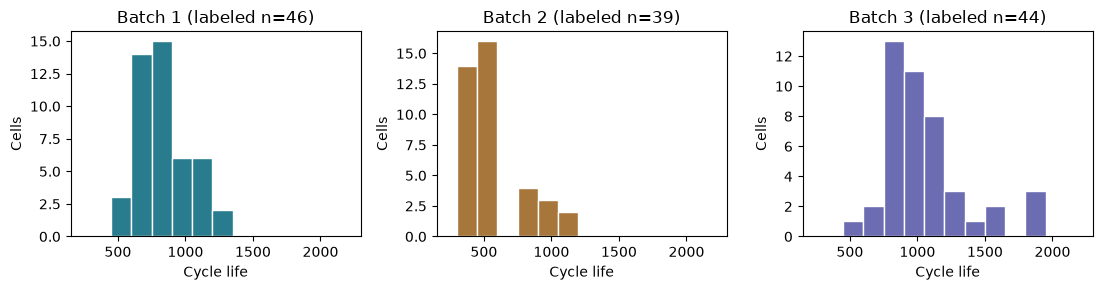

B1: <500회=0/46, >1000회=10/46, <550회=1/46
B2: <500회=28/39, >1000회=3/39, <550회=30/39
B3: <500회=0/44, >1000회=23/44, <550회=1/44


In [3]:
display(batch_stats)
eda.plot_cycle_life(cell_features)
show_figure("01_life.png")
for batch, values in cell_features.groupby("batch"):
    life = values.cycle_life.dropna()
    print(f"B{batch}: <500회={(life < 500).sum()}/{len(life)}, >1000회={(life > 1000).sum()}/{len(life)}, <550회={(life < 550).sum()}/{len(life)}")

### 단수명 셀과 비교군의 초기 신호
B2 안에서 <500회 / ≥500회를 비교합니다. 표는 중앙값이며 원인 추정이나 새 모델 라벨이 아닙니다.

In [4]:
b2_labeled = cell_features.query("batch == 2").dropna(subset=["cycle_life"]).copy()
b2_labeled["life_group"] = np.where(b2_labeled.cycle_life < 500, "<500", ">=500")
features = ["cycle_life", "dq_logvar", "Tavg_mean", "chargetime_mean", "chargetime_median", "C1", "I10_positive_mean"]
display(b2_labeled.groupby("life_group")[features].agg(["count", "median", lambda values: values.quantile(.25), lambda values: values.quantile(.75)]))

cycle_life                              dq_logvar            \
                count median <lambda_0> <lambda_1>     count    median   
life_group                                                               
<500               28  449.5     424.75      474.0        28 -3.446103   
>=500              11  841.0     784.00     1013.0        11 -4.231628   

                                 Tavg_mean             ... chargetime_median  \
           <lambda_0> <lambda_1>     count     median  ...        <lambda_0>   
life_group                                             ...                     
<500        -3.495221  -3.277095        28  32.938183  ...         10.173261   
>=500       -4.308104  -4.116944        11  33.608467  ...         10.039552   

                         C1                              I10_positive_mean  \
           <lambda_1> count median <lambda_0> <lambda_1>             count   
life_group                                                                   
<500        10.177674    28    5.2       4.65        5.6                28   
>=500       10.040654    11    5.2       4.80        5.4                11   

                                            
              median <lambda_0> <lambda_1>  
life_group                                  
<500        2.023131   1.910389   2.136224  
>=500       2.450842   2.442565   2.555835  

[2 rows x 28 columns]

### 배치별 최단 셀과 통계적 이상치 구분
<500회 셀과 IQR 하한 미만의 통계적 이상치는 다른 정의입니다. 각 배치 최단 셀의 정책·초기 신호를 확인합니다.

In [5]:
for batch, values in cell_features.groupby('batch'):
    labeled = values.dropna(subset=['cycle_life'])
    q1, q3 = labeled.cycle_life.quantile([.25, .75])
    lower = q1 - 1.5*(q3-q1)
    print(f'B{batch}: IQR 하한 {lower:.1f}, 하한 미만 {(labeled.cycle_life < lower).sum()}셀')
    display(labeled.nsmallest(3, 'cycle_life')[['cell_id', 'policy', 'cycle_life', 'dq_logvar', 'Tavg_mean', 'C1']])

B1: IQR 하한 386.8, 하한 미만 0셀


,cell_id,policy,cycle_life,dq_logvar,Tavg_mean,C1
20,b1c20,5.4C(80%)-5.4C,534.0,-3.367237,32.126770,5.4
21,b1c21,5.4C(80%)-5.4C,559.0,-3.350338,33.108984,5.4
45,b1c45,8C(35%)-3.6C,599.0,-3.425292,33.019806,8.0


B2: IQR 하한 336.0, 하한 미만 0셀


,cell_id,policy,cycle_life,dq_logvar,Tavg_mean,C1
65,b2c19,6C(60%)-3C,392.0,-3.291958,32.772474,6.0
52,b2c6,3.6C(9%)-5C,393.0,-3.530040,33.817061,3.6
61,b2c15,3.6C(9%)-5C,396.0,-3.516252,32.858335,3.6


B3: IQR 하한 337.1, 하한 미만 0셀


,cell_id,policy,cycle_life,dq_logvar,Tavg_mean,C1
121,b3c28,3.7C(31%)-5.9C-newstructure,541.0,-3.451658,35.722938,3.7
99,b3c6,3.7C(31%)-5.9C-newstructure,667.0,-3.525708,34.115818,3.7
124,b3c31,5.9C(60%)-3.1C-newstructure,731.0,-3.839603,34.011083,5.9


## Q2. 용량 열화와 knee 후보
전체 열화 곡선을 보고 연속 구간 선형 모델을 단일 직선과 비교합니다.
탐색적 지지 기준: SSE 감소 ≥20%, ΔBIC >10, 후반 기울기 < 전반 기울기 <0, 평활 변경 위치 폭 ≤ 관측 범위의 5%.
B1 예시 c0는 기준 미충족입니다. 평활 오차는 독립적이지 않아 BIC를 유의성 검정으로 해석하지 않습니다.

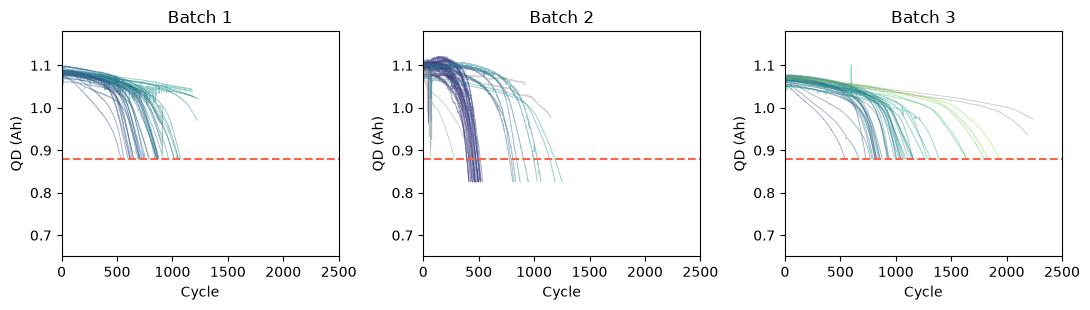

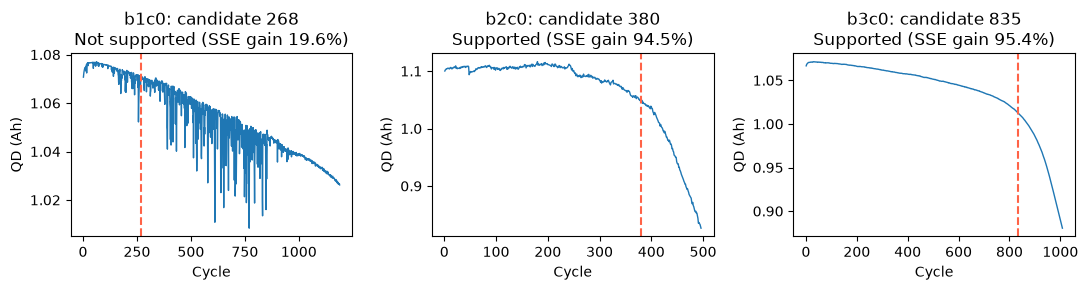

,batch,n,knee_fit_n,knee_supported,sse_gain_median,bic_gain_median,knee_median
0,1,46,46,45,0.969345,2663.014396,599.0
1,2,47,45,44,0.936365,1326.952824,353.0
2,3,46,46,46,0.955239,3184.975582,827.0


knee                         268.0
slope_before             -0.000029
slope_after              -0.000045
sse_gain                  0.195642
bic_gain                242.536633
knee_window11                287.0
knee_window31                268.0
knee_spread_cycles            19.0
knee_relative_spread      0.015993
knee_supported               False
Name: b1c0, dtype: object

In [6]:
eda.plot_degradation(cell_features, capacity_curves)
show_figure("02_degradation.png")
eda.plot_knee_examples(cell_features, capacity_curves)
show_figure("08_knee.png")
eda.save_diagnostic_summaries(cell_features)
diagnostics = pd.read_csv(eda.RESULTS_DIR / "diagnostic_summary.csv")
display(diagnostics[["batch", "n", "knee_fit_n", "knee_supported", "sse_gain_median", "bic_gain_median", "knee_median"]])
# 임의 셀의 계산을 직접 재확인합니다.
cycles, capacity = capacity_curves["b1c0"]
display(pd.Series(eda.knee_diagnostics(cycles, capacity), name="b1c0"))

## Q3. ΔQ100−10의 계산과 통계 피처
실제 전압 축 Vdlin의 각 지점에서 `Qdlin[99] − Qdlin[9]`를 계산합니다.
아래는 한 셀의 ΔQ 배열에서 분산·로그 분산·최소·평균을 다시 계산하여 저장된 피처와 대조하는 과정입니다.

,직접 계산,저장된 값
dq_var,0.000010,0.000010
dq_logvar,-5.014861,-5.014861
dq_min,-0.008460,-0.008460
dq_mean,-0.002873,-0.002873


전압 범위: 2.0 3.5 V / 지점 수: 1000


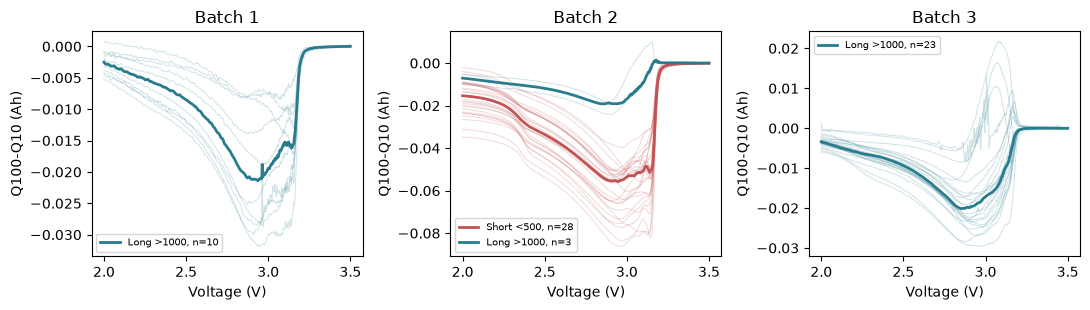

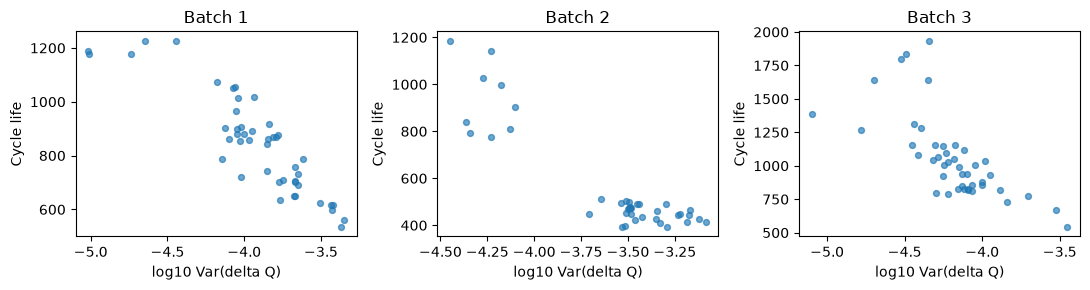

,batch,feature,n,pearson,spearman
0,1,dq_logvar,46,-0.886123,-0.871161
1,1,dq_min,46,0.881645,0.850006
2,1,dq_mean,46,0.853810,0.828112
16,2,dq_logvar,39,-0.901883,-0.708979
17,2,dq_min,39,0.818518,0.660897
18,2,dq_mean,39,0.767085,0.697237
32,3,dq_logvar,44,-0.701862,-0.797237
33,3,dq_min,44,0.692116,0.776024
34,3,dq_mean,44,0.639115,0.756149


In [7]:
voltage, delta_q = delta_curves["b1c0"]
manual_features = {"dq_var": np.var(delta_q), "dq_logvar": np.log10(max(np.var(delta_q), 1e-12)), "dq_min": delta_q.min(), "dq_mean": delta_q.mean()}
saved_features = cell_features.set_index("cell_id").loc["b1c0", list(manual_features)]
display(pd.DataFrame({"직접 계산": manual_features, "저장된 값": saved_features}))
np.testing.assert_allclose(list(manual_features.values()), saved_features.to_numpy(dtype=float))
print("전압 범위:", voltage.min(), voltage.max(), "V / 지점 수:", len(voltage))
eda.plot_delta_curves(cell_features, delta_curves)
show_figure("03_delta.png")
eda.plot_delta_signal(cell_features)
show_figure("04_delta_signal.png")
display(correlations.query("feature in ['dq_logvar', 'dq_min', 'dq_mean']"))

### 상대 수명 그룹과 전압 민감도
B1·B3에는 <500회 셀이 없어 하위/상위 사분위 그룹도 비교합니다. 상대 그룹은 EDA 표시용입니다.
상수 오프셋을 제거해도 분산은 같지만, 다른 측정 구조의 차이가 해결됐다는 의미는 아닙니다.

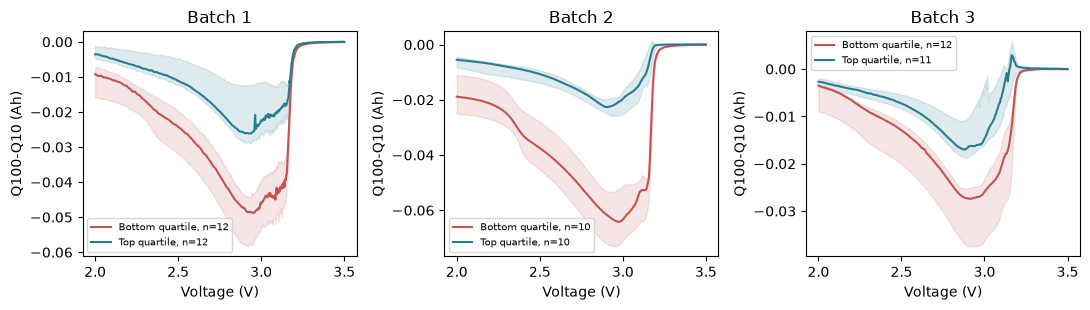

,batch,group,n,cutoff,life_median,dq_logvar_median
0,1,Bottom quartile,12,703.25,630.5,-3.577307
1,1,Top quartile,12,914.25,1064.0,-4.125196
2,2,Bottom quartile,10,439.50,414.0,-3.339519
3,2,Top quartile,10,508.50,872.5,-4.231649
4,3,Bottom quartile,12,828.00,804.5,-4.079074
5,3,Top quartile,11,1155.25,1390.0,-4.454635


,batch,anchor_max_abs,centered_max_difference,full_core_spearman
0,1,0.000398,8.881784e-16,0.983102
1,2,0.001086,8.881784e-16,0.882747
2,3,0.000197,8.881784e-16,0.903793


In [8]:
eda.plot_relative_delta(cell_features, delta_curves)
show_figure("09_delta_relative.png")
display(pd.read_csv(eda.RESULTS_DIR / "relative_delta_groups.csv"))
display(diagnostics[["batch", "anchor_max_abs", "centered_max_difference", "full_core_spearman"]])

## Q4. 충전 정책·전류 조건과 수명
정책별 n/평균/표준편차를 표시합니다. 표준편차를 계산할 수 없는 n=1을 분산 0으로 해석하지 않습니다.
첫 단계 C-rate와 수명 관계는 배치별 부호가 달라 인과효과로 해석할 수 없습니다.

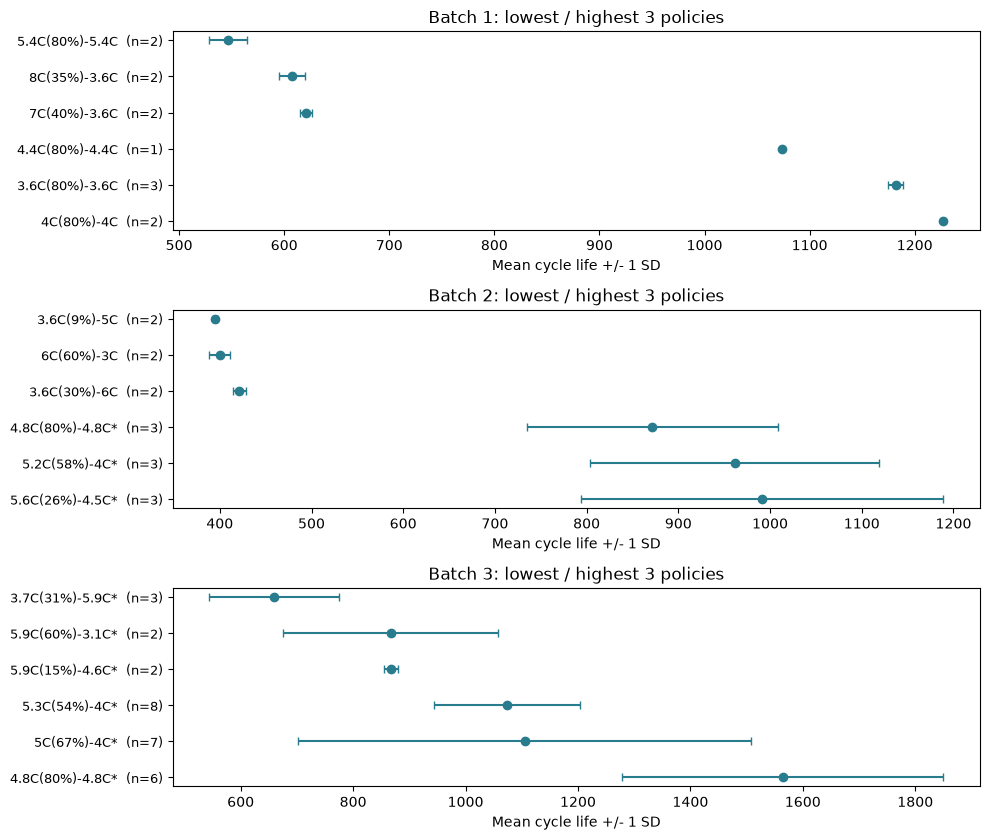

,batch,policy,count,mean,std
0,1,3.6C(80%)-3.6C,3,1182.000000,7.000000
1,1,4.4C(80%)-4.4C,1,1074.000000,NaN
2,1,4.8C(80%)-4.8C,2,753.000000,165.462987
3,1,4C(80%)-4C,2,1226.500000,0.707107
4,1,5.4C(40%)-3.6C,2,966.500000,123.743687
5,1,5.4C(50%)-3.6C,2,899.500000,3.535534
6,1,5.4C(50%)-3C,2,847.000000,83.438600
7,1,5.4C(60%)-3.6C,2,859.500000,3.535534
8,1,5.4C(60%)-3C,2,799.500000,113.844192
9,1,5.4C(70%)-3C,2,739.500000,68.589358


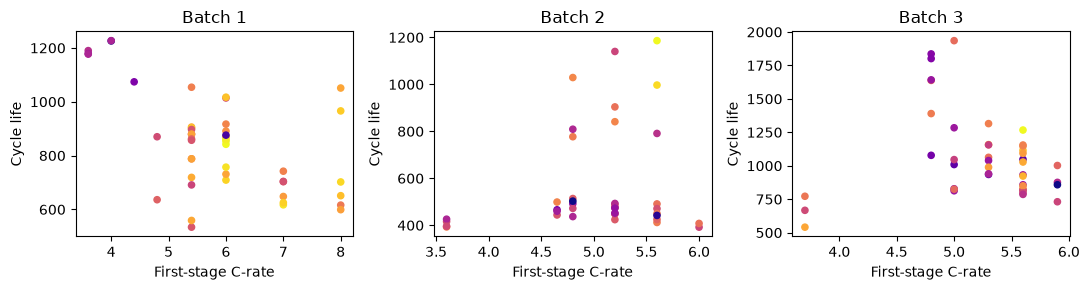

,batch,feature,n,pearson,spearman
4,1,QD_early_slope,46,0.524086,0.578019
10,1,C1,46,-0.579719,-0.482714
11,1,C2,46,-0.095887,0.047414
12,1,I10_positive_mean,46,-0.525353,-0.628469
20,2,QD_early_slope,39,-0.484422,-0.270979
26,2,C1,39,0.190747,0.055093
27,2,C2,39,-0.116305,-0.118840
28,2,I10_positive_mean,39,0.758005,0.505922
36,3,QD_early_slope,44,0.360500,0.184157
42,3,C1,44,-0.082899,-0.228875


In [9]:
eda.plot_policy_life(cell_features)
show_figure("05_policy.png")
display(pd.read_csv(eda.RESULTS_DIR / "policy_stats.csv"))
eda.plot_charge_rate(cell_features)
show_figure("06_crate.png")
display(correlations.query("feature in ['C1', 'C2', 'I10_positive_mean', 'QD_early_slope']"))

### 실제 I(t) 패턴을 직접 확인
각 배치의 c0·c14를 고정해 10회 사이클의 전류를 표시합니다. 양수 충전 구간의 단계 전환과 후반 감소를 관찰하세요.
정책의 명목 전류 점선은 실제 SOC가 아닙니다. 표의 초기 용량 기울기와 ΔQ 신호를 함께 보되 6개 예시로 인과성을 주장하지 않습니다.

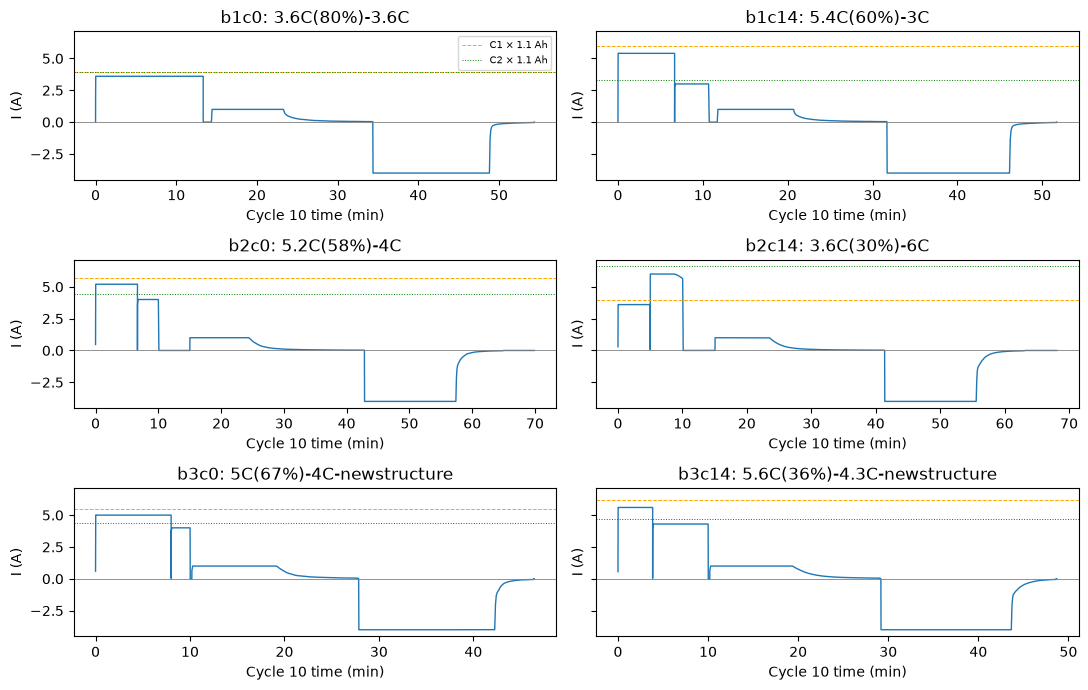

,cell_id,policy,cycle_life,QD_early_slope,dq_logvar
0,b1c0,3.6C(80%)-3.6C,1190.0,0.000003,-5.014861
14,b1c14,5.4C(60%)-3C,880.0,0.000016,-4.046070
46,b2c0,5.2C(58%)-4C,477.0,0.000010,-3.487265
60,b2c14,3.6C(30%)-6C,426.0,-0.000100,-3.118520
93,b3c0,5C(67%)-4C-newstructure,1009.0,-0.000015,-4.245115
107,b3c14,5.6C(36%)-4.3C-newstructure,858.0,-0.000007,-3.999668


In [10]:
patterns, durations = charge.load_charge_records()
charge.plot_current_patterns(patterns, cell_features)
show_figure("10_current_patterns.png")
display(cell_features.loc[cell_features.cell_id.isin(patterns), ["cell_id", "policy", "cycle_life", "QD_early_slope", "dq_logvar"]])

### 충전시간 극단 기록의 출처
평균 53분대가 나온 셀을 사이클별로 확인합니다. 예: b2c14의 50회, b2c32의 71회에 약 3,934분 기록이 있습니다.
극단값의 원인이 실제 충전·휴지 시간·실험 중단·기록 문제 중 무엇인지는 아직 확인되지 않았습니다.
중앙값을 B의 기본 피처로 두고 평균/제외를 동일 B1 CV에서 비교합니다. 30분 경계는 집계용이며 자동 삭제 기준이 아닙니다.

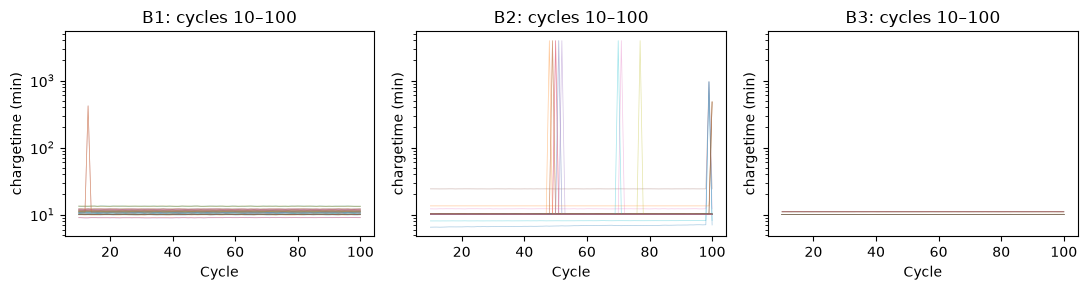

,batch,early_records_n,gt30_records_n,gt30_cells_n,max_minutes
0,1,4186,3,3,419.873355
1,2,4277,19,18,3934.705167
2,3,4186,0,0,11.070910


,batch,cell_id,cycle,chargetime
5500,2,b2c14,50.0,3934.705167
6046,2,b2c20,50.0,3932.592797
6593,2,b2c26,51.0,3933.121078
6773,2,b2c28,49.0,3933.736147
6958,2,b2c30,52.0,3933.400758
7159,2,b2c32,71.0,3933.455188
7347,2,b2c34,77.0,3934.123772
7865,2,b2c40,49.0,3932.943618
7958,2,b2c41,51.0,3933.623047
8250,2,b2c44,70.0,3932.507030


,cell_id,chargetime_mean,chargetime_median,chargetime_max,chargetime_gt30_n
60,b2c14,53.367222,10.245440,3934.705167,1
66,b2c20,53.276475,10.172940,3932.592797,1
68,b2c22,34.497785,24.217242,960.085473,1
72,b2c26,53.303939,10.177438,3933.121078,1
74,b2c28,53.289495,10.173290,3933.736147,1
76,b2c30,53.311883,10.179322,3933.400758,1
78,b2c32,53.155371,10.040875,3933.455188,1
80,b2c34,53.162244,10.040187,3934.123772,1
86,b2c40,58.445709,10.173168,3932.943618,2
87,b2c41,53.304792,10.177142,3933.623047,1


In [11]:
charge.plot_charge_time_records(durations)
show_figure("11_charge_time.png")
charge.save_charge_audit(durations, cell_features)
display(pd.read_csv(eda.RESULTS_DIR / "charge_time_audit.csv"))
display(durations.query("chargetime > 1000").sort_values(["batch", "cell_id", "cycle"]))
display(cell_features.loc[cell_features.chargetime_mean > 30, ["cell_id", "chargetime_mean", "chargetime_median", "chargetime_max", "chargetime_gt30_n"]])

### 전류 패턴 요약과 초기 용량 변화율의 직접 상관
기울기 <0은 초기 용량 감소, >0은 증가입니다. 수명 결측 셀도 두 초기 피처가 있으면 포함합니다.

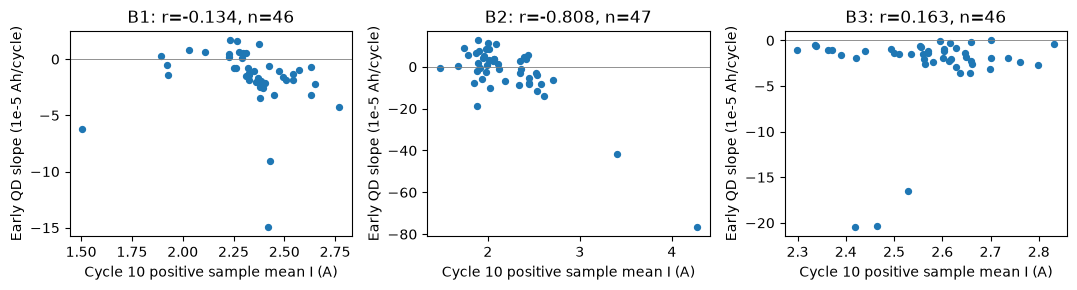

,batch,n,Pearson,Spearman
0,1,46,-0.133791,-0.551773
1,2,47,-0.808194,-0.477220
2,3,46,0.162520,-0.177058


In [12]:
charge.plot_current_degradation(cell_features)
show_figure('12_current_degradation.png')
rows = []
for batch, values in cell_features.groupby('batch'):
    pairs = values[['I10_positive_mean', 'QD_early_slope']].dropna()
    rows.append({'batch':batch, 'n':len(pairs), 'Pearson':pairs.I10_positive_mean.corr(pairs.QD_early_slope), 'Spearman':pairs.I10_positive_mean.corr(pairs.QD_early_slope, method='spearman')})
display(pd.DataFrame(rows))

## Q5. 초기 신호의 상관관계와 다중공선성
Pearson과 Spearman을 함께 확인하고 결측 쌍별 유효 n을 표시합니다. 상관관계는 예측 성능이 아닙니다.
Tavg/Tmax의 중복을 피하고, QD100−QD10은 배치별 부호가 달라 추가 검증 후보로 둡니다.

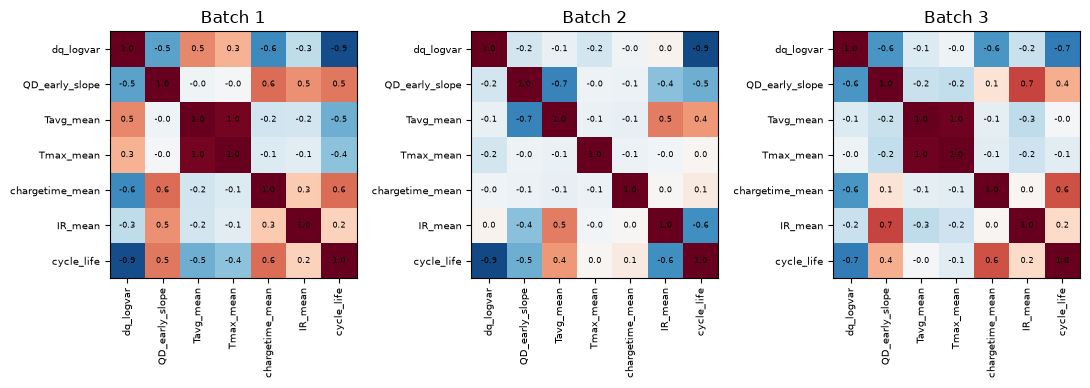

,batch,feature,n,pearson,spearman
0,1,dq_logvar,46,-0.886123,-0.871161
1,1,dq_min,46,0.881645,0.850006
2,1,dq_mean,46,0.853810,0.828112
3,1,QD_early_mean,46,0.214584,0.240656
4,1,QD_early_slope,46,0.524086,0.578019
5,1,IR_mean,46,0.231164,0.188849
6,1,Tavg_mean,46,-0.485946,-0.371469
7,1,Tmax_mean,46,-0.407365,-0.321512
8,1,chargetime_mean,46,0.555672,0.616689
9,1,chargetime_median,46,0.745130,0.638461


B1: Tavg/Tmax r=0.956
B2: Tavg/Tmax r=-0.065
B3: Tavg/Tmax r=0.971


In [13]:
eda.plot_feature_correlations(cell_features)
show_figure("07_corr.png")
display(correlations)
for batch, values in cell_features.groupby("batch"):
    print(f"B{batch}: Tavg/Tmax r={values.Tavg_mean.corr(values.Tmax_mean):.3f}")

### 가장 강한 수명 관계와 피처 중복
민감도 변형을 제외한 초기 피처에서 절대 Pearson 상관을 비교합니다. B2의 충전시간 중앙값은 ΔQ보다 강하지만 부호가 배치별로 바뀝니다. 가장 강한 상관과 최적 예측 모델은 다릅니다.

In [14]:
candidates = correlations.query("feature not in ['dq_core_logvar', 'dq_centered_logvar']").copy()
candidates['abs_r'] = candidates.pearson.abs()
display(candidates.sort_values(['batch', 'abs_r'], ascending=[True, False]).groupby('batch').head(3))
for batch, values in cell_features.groupby('batch'):
    print(f'B{batch} 초기 피처 간 Pearson 상관')
    display(values[['dq_logvar', 'dq_min', 'dq_mean', 'QD_early_slope', 'QD100_minus_QD10', 'Tavg_mean', 'Tmax_mean', 'chargetime_median']].corr())

,batch,feature,n,pearson,spearman,abs_r
0,1,dq_logvar,46,-0.886123,-0.871161,0.886123
1,1,dq_min,46,0.881645,0.850006,0.881645
2,1,dq_mean,46,0.853810,0.828112,0.853810
25,2,chargetime_median,39,-0.915886,-0.808685,0.915886
16,2,dq_logvar,39,-0.901883,-0.708979,0.901883
17,2,dq_min,39,0.818518,0.660897,0.818518
32,3,dq_logvar,44,-0.701862,-0.797237,0.701862
33,3,dq_min,44,0.692116,0.776024,0.692116
34,3,dq_mean,44,0.639115,0.756149,0.639115


B1 초기 피처 간 Pearson 상관


,dq_logvar,dq_min,dq_mean,QD_early_slope,QD100_minus_QD10,Tavg_mean,Tmax_mean,chargetime_median
dq_logvar,1.000000,-0.946980,-0.926174,-0.537905,-0.589094,0.476664,0.344984,-0.808940
dq_min,-0.946980,1.000000,0.992510,0.681926,0.712829,-0.396810,-0.293459,0.770008
dq_mean,-0.926174,0.992510,1.000000,0.713907,0.745243,-0.356411,-0.257676,0.763886
QD_early_slope,-0.537905,0.681926,0.713907,1.000000,0.977011,-0.046474,-0.012138,0.516320
QD100_minus_QD10,-0.589094,0.712829,0.745243,0.977011,1.000000,-0.039170,-0.000369,0.603098
Tavg_mean,0.476664,-0.396810,-0.356411,-0.046474,-0.039170,1.000000,0.956457,-0.220302
Tmax_mean,0.344984,-0.293459,-0.257676,-0.012138,-0.000369,0.956457,1.000000,-0.149301
chargetime_median,-0.808940,0.770008,0.763886,0.516320,0.603098,-0.220302,-0.149301,1.000000


B2 초기 피처 간 Pearson 상관


,dq_logvar,dq_min,dq_mean,QD_early_slope,QD100_minus_QD10,Tavg_mean,Tmax_mean,chargetime_median
dq_logvar,1.000000,-0.929554,-0.897200,-0.180116,-0.221742,-0.072213,-0.180052,-0.468800
dq_min,-0.929554,1.000000,0.974980,0.425165,0.450421,-0.090153,0.094100,0.446343
dq_mean,-0.897200,0.974980,1.000000,0.545603,0.575265,-0.189278,0.119493,0.433835
QD_early_slope,-0.180116,0.425165,0.545603,1.000000,0.967025,-0.664343,-0.047104,0.241818
QD100_minus_QD10,-0.221742,0.450421,0.575265,0.967025,1.000000,-0.678028,-0.420893,0.121194
Tavg_mean,-0.072213,-0.090153,-0.189278,-0.664343,-0.678028,1.000000,-0.064912,-0.038971
Tmax_mean,-0.180052,0.094100,0.119493,-0.047104,-0.420893,-0.064912,1.000000,-0.017742
chargetime_median,-0.468800,0.446343,0.433835,0.241818,0.121194,-0.038971,-0.017742,1.000000


B3 초기 피처 간 Pearson 상관


,dq_logvar,dq_min,dq_mean,QD_early_slope,QD100_minus_QD10,Tavg_mean,Tmax_mean,chargetime_median
dq_logvar,1.000000,-0.926314,-0.899895,-0.584878,-0.564940,-0.133414,-0.049385,-0.585550
dq_min,-0.926314,1.000000,0.990454,0.740142,0.721735,0.029250,-0.030819,0.510202
dq_mean,-0.899895,0.990454,1.000000,0.787953,0.773883,-0.005703,-0.062677,0.456040
QD_early_slope,-0.584878,0.740142,0.787953,1.000000,0.992239,-0.224132,-0.246175,0.140263
QD100_minus_QD10,-0.564940,0.721735,0.773883,0.992239,1.000000,-0.227568,-0.244409,0.111947
Tavg_mean,-0.133414,0.029250,-0.005703,-0.224132,-0.227568,1.000000,0.970636,-0.101508
Tmax_mean,-0.049385,-0.030819,-0.062677,-0.246175,-0.244409,0.970636,1.000000,-0.115119
chargetime_median,-0.585550,0.510202,0.456040,0.140263,0.111947,-0.101508,-0.115119,1.000000


## 데이터 품질 민감도
B1 원본 46셀 유지가 주 분석이며 끝 용량 >0.885Ah 후보를 자동 삭제하지 않습니다.
전체 수명 품질 플래그는 모델 입력이 아닙니다. 제외 보조 모델도 같은 검증 셀로 비교해야 합니다.

In [15]:
display(diagnostics[["batch", "raw_label_n", "unflagged_label_n", "raw_dq_r", "unflagged_dq_r"]])
display(cell_features.groupby("batch")[["bad_QD_rows", "endpoint_quality_flag"]].sum())

,batch,raw_label_n,unflagged_label_n,raw_dq_r,unflagged_dq_r
0,1,46,36,-0.886123,-0.826584
1,2,39,39,-0.901883,-0.901883
2,3,44,44,-0.701862,-0.701862


,bad_QD_rows,endpoint_quality_flag
batch,,
1,48,10
2,11,4
3,0,2


## EDA → 모델 전략
- 타깃: 초기 100회로 총 `cycle_life`를 예측하는 회귀. 성능은 아직 미측정.
- A: dq_logvar.
- B: A + QD_early_slope + Tavg_mean + chargetime_median.
- C: B + C1 + switch_pct + C2.
- 1차: 중앙값 Dummy, A 선형 회귀, B/C Ridge. alpha={0.1,1,10}, 원/로그 타깃.
- 추가: B+QD100_minus_QD10 및 기울기 대체 Ridge; B의 충전시간을 평균/제외로 바꾼 Ridge. 같은 CV와 1-SE 규칙 적용.
- B1 정책 그룹 hold-out(seed=42)과 개발 데이터 GroupKFold(5). 전처리는 fold train에서만 fit.
- 모든 비교를 hold-out 확인 전에 확정. 선택 고정 후 전체 B1로 재학습하고 B2·B3 평가.
- B2·B3 라벨을 EDA에서 봤으므로 완전한 blind test로 주장하지 않음.

전류·충전시간의 품질 확인은 도메인 관찰이며 B2 예측 성능으로 규칙을 조정하지 않습니다.

In [16]:
feature_sets = {
    "A": ["dq_logvar"],
    "B": ["dq_logvar", "QD_early_slope", "Tavg_mean", "chargetime_median"],
    "C": ["dq_logvar", "QD_early_slope", "Tavg_mean", "chargetime_median", "C1", "switch_pct", "C2"],
}
for name, features in feature_sets.items():
    print(name, features)
    display(cell_features.groupby("batch")[features].count())
assert diagnostics.knee_fit_n.tolist() == [46, 45, 46]
assert diagnostics.knee_supported.tolist() == [45, 44, 46]
print("EDA 계산 및 주요 숫자 검증 완료. 모델 학습은 수행하지 않았습니다.")

A ['dq_logvar']


,dq_logvar
batch,
1,46
2,47
3,46


B ['dq_logvar', 'QD_early_slope', 'Tavg_mean', 'chargetime_median']


,dq_logvar,QD_early_slope,Tavg_mean,chargetime_median
batch,,,,
1,46,46,46,46
2,47,47,47,47
3,46,46,46,46


C ['dq_logvar', 'QD_early_slope', 'Tavg_mean', 'chargetime_median', 'C1', 'switch_pct', 'C2']


,dq_logvar,QD_early_slope,Tavg_mean,chargetime_median,C1,switch_pct,C2
batch,,,,,,,
1,46,46,46,46,46,46,46
2,47,47,47,47,43,43,43
3,46,46,46,46,46,46,46


EDA 계산 및 주요 숫자 검증 완료. 모델 학습은 수행하지 않았습니다.
